# Optiminacion
Se usara un data set de imagenes de comida, cada imagen esta convertida en un vector de 4096 pixeles (64x64)

Datos de entrenamiento: 75750

Datos de prueba: 25250

El dataset consta de 4097 columnas, las primeras 4096 son cada valor de un pixel en escala de grises, osea que solo se toma en cuenta la intensidad de luz, recordemos que estos valores pueden ir del 0 al 254, mientras mas grande el numero mas oscuro.

Link del dataset: https://www.kaggle.com/datasets/ahmadrezaahangarian/food-images-grayscale-csv

In [1]:
import pandas as pd
import torch
import numpy as np

El dataset cuenta con 101 clases, esto hace dificultoso al momento de hacer calculos, por lo que se lo generalizara a 9 clases principales, las clases anteriores eran:

    'apple_pie',
    'baby_back_ribs',
    'baklava',
    'beef_carpaccio',
    'beef_tartare',
    'beet_salad',
    'beignets',
    'bibimbap',
    'bread_pudding',
    'breakfast_burrito',
    'bruschetta',
    'caesar_salad',
    'cannoli',
    'caprese_salad',
    'carrot_cake',
    'ceviche',
    'cheesecake',
    'cheese_plate',
    'chicken_curry',
    'chicken_quesadilla',
    'chicken_wings',
    'chocolate_cake',
    'chocolate_mousse',
    'churros',
    'clam_chowder',
    'club_sandwich',
    'crab_cakes',
    'creme_brulee',
    'croque_madame',
    'cup_cakes',
    'deviled_eggs',
    'donuts',
    'dumplings',
    'edamame',
    'eggs_benedict',
    'escargots',
    'falafel',
    'filet_mignon',
    'fish_and_chips',
    'foie_gras',
    'french_fries',
    'french_onion_soup',
    'french_toast',
    'fried_calamari',
    'fried_rice',
    'frozen_yogurt',
    'garlic_bread',
    'gnocchi',
    'greek_salad',
    'grilled_cheese_sandwich',
    'grilled_salmon',
    'guacamole',
    'gyoza',
    'hamburger',
    'hot_and_sour_soup',
    'hot_dog',
    'huevos_rancheros',
    'hummus',
    'ice_cream',
    'lasagna',
    'lobster_bisque',
    'lobster_roll_sandwich',
    'macaroni_and_cheese',
    'macarons',
    'miso_soup',
    'mussels',
    'nachos',
    'omelette',
    'onion_rings',
    'oysters',
    'pad_thai',
    'paella',
    'pancakes',
    'panna_cotta',
    'peking_duck',
    'pho',
    'pizza',
    'pork_chop',
    'poutine',
    'prime_rib',
    'pulled_pork_sandwich',
    'ramen',
    'ravioli',
    'red_velvet_cake',
    'risotto',
    'samosa',
    'sashimi',
    'scallops',
    'seaweed_salad',
    'shrimp_and_grits',
    'spaghetti_bolognese',
    'spaghetti_carbonara',
    'spring_rolls',
    'steak',
    'strawberry_shortcake',
    'sushi',
    'tacos',
    'takoyaki',
    'tiramisu',
    'tuna_tartare',
    'waffles'

Ahora las clases seran 

'Pasteles y postres' = 0,

'Carnes' = 1,

'Mariscos y pescados' = 2,

'Comida rapida' = 3,

'Enlatadas y vegetales' = 4,

'Sopas y platos asiaticos' = 5,

'Pastas' = 6,

'Huevos' = 7,

'Otros' = 8

In [2]:
general_mapping = {
    # Pasteles y postres
    0: 0, 2:0, 8:0, 14:0, 16:0, 21:0, 22:0, 23:0, 29:0, 31:0, 45:0, 58:0, 63:0, 73:0, 83:0, 94:0, 98:0, 100:0,
    
    # Carnes
    1:1, 3:1, 4:1, 18:1, 20:1, 37:1, 50:1, 53:1, 77:1, 79:1, 80:1, 93:1, 99:1,
    
    # Mariscos y pescados
    15:2, 24:2, 26:2, 38:2, 60:2, 61:2, 65:2, 69:2, 86:2, 87:2, 89:2,
    
    # Comida rápida
    7:3, 9:3, 10:3, 25:3, 40:3, 44:3, 46:3, 49:3, 53:3, 55:3, 66:3, 68:3, 76:3, 78:3, 92:3, 96:3, 97:3,
    
    # Ensaladas y vegetales
    5:4, 11:4, 13:4, 33:4, 48:4, 57:4, 88:4,
    
    # Sopas y platos asiáticos
    32:5, 41:5, 54:5, 64:5, 70:5, 75:5, 81:5, 84:5,
    
    # Pastas
    59:6, 62:6, 82:6, 90:6, 91:6,
    
    # Huevos
    30:7, 34:7, 67:7, 56:7,
    
    # Otros
    6:8, 12:8, 19:8, 27:8, 35:8, 36:8, 39:8, 42:8, 43:8, 47:8, 51:8, 52:8, 71:8, 72:8, 74:8, 85:8, 95:8
}

In [ ]:
trainset = pd.read_csv('train.csv', delimiter=',')
trainset.rename(columns={"0": "food"}, inplace=True)
testset = pd.read_csv('test.csv', delimiter=',')
testset.rename(columns={"0": "food"}, inplace=True)
print(trainset.iloc[:, -1])
print(testset.iloc[:, -1])
len(trainset), len(testset)

0         9
1        12
2        19
3        37
4        70
         ..
75745    58
75746    24
75747     8
75748    88
75749    87
Name: food, Length: 75750, dtype: int64
0        64
1        92
2         6
3        96
4        41
         ..
25245    72
25246    56
25247    38
25248     1
25249    38
Name: food, Length: 25250, dtype: int64


(75750, 25250)

# Importando la clase de cada imagen

El dataset nos da como estan representadas las imagenes o que valor tienen estas las almacenamos en la variable classes que es una tupla

In [4]:
general_mapping = {
    # Pasteles y postres
    0: 0, 2:0, 8:0, 14:0, 16:0, 21:0, 22:0, 23:0, 29:0, 31:0, 45:0, 58:0, 63:0, 73:0, 83:0, 94:0, 98:0, 100:0,
    
    # Carnes
    1:1, 3:1, 4:1, 18:1, 20:1, 37:1, 50:1, 53:1, 77:1, 79:1, 80:1, 93:1, 99:1,
    
    # Mariscos y pescados
    15:2, 24:2, 26:2, 38:2, 60:2, 61:2, 65:2, 69:2, 86:2, 87:2, 89:2,
    
    # Comida rápida
    7:3, 9:3, 10:3, 25:3, 40:3, 44:3, 46:3, 49:3, 53:3, 55:3, 66:3, 68:3, 76:3, 78:3, 92:3, 96:3, 97:3,
    
    # Ensaladas y vegetales
    5:4, 11:4, 13:4, 33:4, 48:4, 57:4, 88:4,
    
    # Sopas y platos asiáticos
    32:5, 41:5, 54:5, 64:5, 70:5, 75:5, 81:5, 84:5,
    
    # Pastas
    59:6, 62:6, 82:6, 90:6, 91:6,
    
    # Huevos
    30:7, 34:7, 67:7, 56:7,
    
    # Otros
    6:8, 12:8, 19:8, 27:8, 35:8, 36:8, 39:8, 42:8, 43:8, 47:8, 51:8, 52:8, 71:8, 72:8, 74:8, 85:8, 95:8
}

Usamos el dataset de train para los datos de prueba, ahora antes trabajabamos solo con  train y test pero a partir de este momento se usara otro dato conocido como val

Este seria la validacion, se usa mientras se entrena para ajustar hiperparametros

Se esta usando el 20% de los datos de train para sacar el val.


In [ ]:
from sklearn.model_selection import train_test_split

X = trainset.iloc[:, :-1].to_numpy()
y = trainset.iloc[:, -1].to_numpy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42)
X_subset, _, y_subset, _ = train_test_split(X_train, y_train, test_size=0.9, random_state=42)

#imprimir las dimensiones de cada conjunto
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_subset.shape, y_subset.shape

# Reemplazar etiquetas en tus datasets
y_train = np.array([general_mapping.get(label, 8) for label in y_train])
y_val   = np.array([general_mapping.get(label, 8) for label in y_val])
y_subset= np.array([general_mapping.get(label, 8) for label in y_subset])

# Revisar número de clases generales
print("Número de clases generales:", len(np.unique(y_train)))


#para los datos de prueba
X_test = testset.iloc[:, :-1].to_numpy()
y_test = testset.iloc[:, -1].to_numpy()
y_test = np.array([general_mapping.get(label, 8) for label in y_test])
X_test.shape, y_test.shape


Número de clases generales: 9


Normalizamos los datos

In [6]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        # Solo normalización - sin view redundante
        self.X = torch.from_numpy(X / 255.0).float().cuda()
        self.Y = torch.from_numpy(Y).long().cuda()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}
dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(71962, 3788)

In [10]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=64*64, H=110, D_out=9):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # cálculo de accuracy en PyTorch
            y_probas = torch.argmax(y_pred, dim=1)
            _acc.append((y_probas == y_b).float().mean().item())

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(y_pred, dim=1)
                _acc.append((y_probas == y_b).float().mean().item())

        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


Los resultados que iremos viendo no seran muy apreciados ya que se esta usando las imagenes de forma plana osea Multi-Layer Perceptron (MLP) osea una red neuronal clasica y esto hace que sea muy limitado el aprendije para imagenes

# Optimizadores

1. Descenso de Gradiente Estocástico (SGD)

In [11]:
import numpy as np

model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.19536 en epoch 1
Mejor modelo guardado con acc 0.19583 en epoch 4
Mejor modelo guardado con acc 0.19916 en epoch 5
Mejor modelo guardado con acc 0.20291 en epoch 6
Mejor modelo guardado con acc 0.20689 en epoch 8
Mejor modelo guardado con acc 0.21256 en epoch 10
Epoch 10/100 loss 2.05317 acc 0.20346 val_loss 2.04596 val_acc 0.21256
Mejor modelo guardado con acc 0.21340 en epoch 14
Mejor modelo guardado con acc 0.21356 en epoch 18
Mejor modelo guardado con acc 0.21686 en epoch 19
Epoch 20/100 loss 2.04176 acc 0.21516 val_loss 2.03690 val_acc 0.21139
Mejor modelo guardado con acc 0.21856 en epoch 22
Mejor modelo guardado con acc 0.22204 en epoch 27
Epoch 30/100 loss 2.03064 acc 0.22365 val_loss 2.02917 val_acc 0.21629
Epoch 40/100 loss 2.02042 acc 0.22965 val_loss 2.02363 val_acc 0.21764
Mejor modelo guardado con acc 0.22238 en epoch 42
Mejor modelo guardado con acc 0.22422 en epoch 46
Mejor modelo guardado con acc 0.22599 en epoch 50
Epoch 50/100 loss 2.0

Estos resultados indican que pudo haber overfitting, se iso la comprobacion para diferentes valores pero no s epudo evitar y podemos ver el limite que tiene el usar MLP

1. SGD

2. Momentum

In [12]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.20437 en epoch 1
Mejor modelo guardado con acc 0.21239 en epoch 3
Mejor modelo guardado con acc 0.21817 en epoch 4
Mejor modelo guardado con acc 0.21832 en epoch 7
Mejor modelo guardado con acc 0.23827 en epoch 8
Epoch 10/100 loss 2.01106 acc 0.23213 val_loss 2.01040 val_acc 0.23168
Mejor modelo guardado con acc 0.24093 en epoch 19
Epoch 20/100 loss 1.97676 acc 0.24926 val_loss 2.00006 val_acc 0.23443
Epoch 30/100 loss 1.94949 acc 0.26235 val_loss 2.01065 val_acc 0.23768
Epoch 40/100 loss 1.91929 acc 0.27644 val_loss 2.01217 val_acc 0.23176
Epoch 50/100 loss 1.88576 acc 0.29565 val_loss 2.02534 val_acc 0.22504
Epoch 60/100 loss 1.85287 acc 0.30802 val_loss 2.05806 val_acc 0.21957
Epoch 70/100 loss 1.81087 acc 0.32666 val_loss 2.07564 val_acc 0.22419
Epoch 80/100 loss 1.77153 acc 0.34392 val_loss 2.12884 val_acc 0.21346
Epoch 90/100 loss 1.72957 acc 0.36272 val_loss 2.17784 val_acc 0.21110
Epoch 100/100 loss 1.68044 acc 0.38245 val_loss 2.24769 val_acc 0.

3. RMS-prop

In [13]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.19576 en epoch 1
Mejor modelo guardado con acc 0.20775 en epoch 2
Mejor modelo guardado con acc 0.21030 en epoch 3
Mejor modelo guardado con acc 0.21050 en epoch 4
Mejor modelo guardado con acc 0.22352 en epoch 5
Mejor modelo guardado con acc 0.22916 en epoch 7
Epoch 10/100 loss 2.03278 acc 0.21791 val_loss 2.03002 val_acc 0.21615
Epoch 20/100 loss 2.02677 acc 0.21655 val_loss 2.02894 val_acc 0.21541
Epoch 30/100 loss 2.02469 acc 0.21904 val_loss 2.03626 val_acc 0.21253
Epoch 40/100 loss 2.02112 acc 0.21879 val_loss 2.06365 val_acc 0.20376
Epoch 50/100 loss 2.01897 acc 0.21936 val_loss 2.04241 val_acc 0.20885
Epoch 60/100 loss 2.01815 acc 0.22048 val_loss 2.07889 val_acc 0.20134
Epoch 70/100 loss 2.01768 acc 0.21840 val_loss 2.06681 val_acc 0.20735
Epoch 80/100 loss 2.01480 acc 0.22131 val_loss 2.07795 val_acc 0.21301
Epoch 90/100 loss 2.01713 acc 0.21950 val_loss 2.04956 val_acc 0.21591
Epoch 100/100 loss 2.01537 acc 0.21905 val_loss 2.08243 val_acc 0.2

4. Adam

In [14]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.17209 en epoch 1
Mejor modelo guardado con acc 0.20397 en epoch 2
Mejor modelo guardado con acc 0.21829 en epoch 5
Mejor modelo guardado con acc 0.22263 en epoch 9
Epoch 10/100 loss 2.03562 acc 0.21441 val_loss 2.03598 val_acc 0.21063
Mejor modelo guardado con acc 0.22279 en epoch 11
Mejor modelo guardado con acc 0.22422 en epoch 18
Epoch 20/100 loss 2.03023 acc 0.21749 val_loss 2.03497 val_acc 0.21782
Epoch 30/100 loss 2.02684 acc 0.21887 val_loss 2.04383 val_acc 0.21184
Epoch 40/100 loss 2.02430 acc 0.21934 val_loss 2.04420 val_acc 0.20789
Epoch 50/100 loss 2.02129 acc 0.22014 val_loss 2.04079 val_acc 0.22070
Epoch 60/100 loss 2.01874 acc 0.22129 val_loss 2.04243 val_acc 0.20788
Epoch 70/100 loss 2.01745 acc 0.22371 val_loss 2.04228 val_acc 0.20783
Epoch 80/100 loss 2.01526 acc 0.22223 val_loss 2.05096 val_acc 0.21040
Epoch 90/100 loss 2.01298 acc 0.22348 val_loss 2.04410 val_acc 0.20635
Epoch 100/100 loss 2.01041 acc 0.22323 val_loss 2.05823 val_acc 0

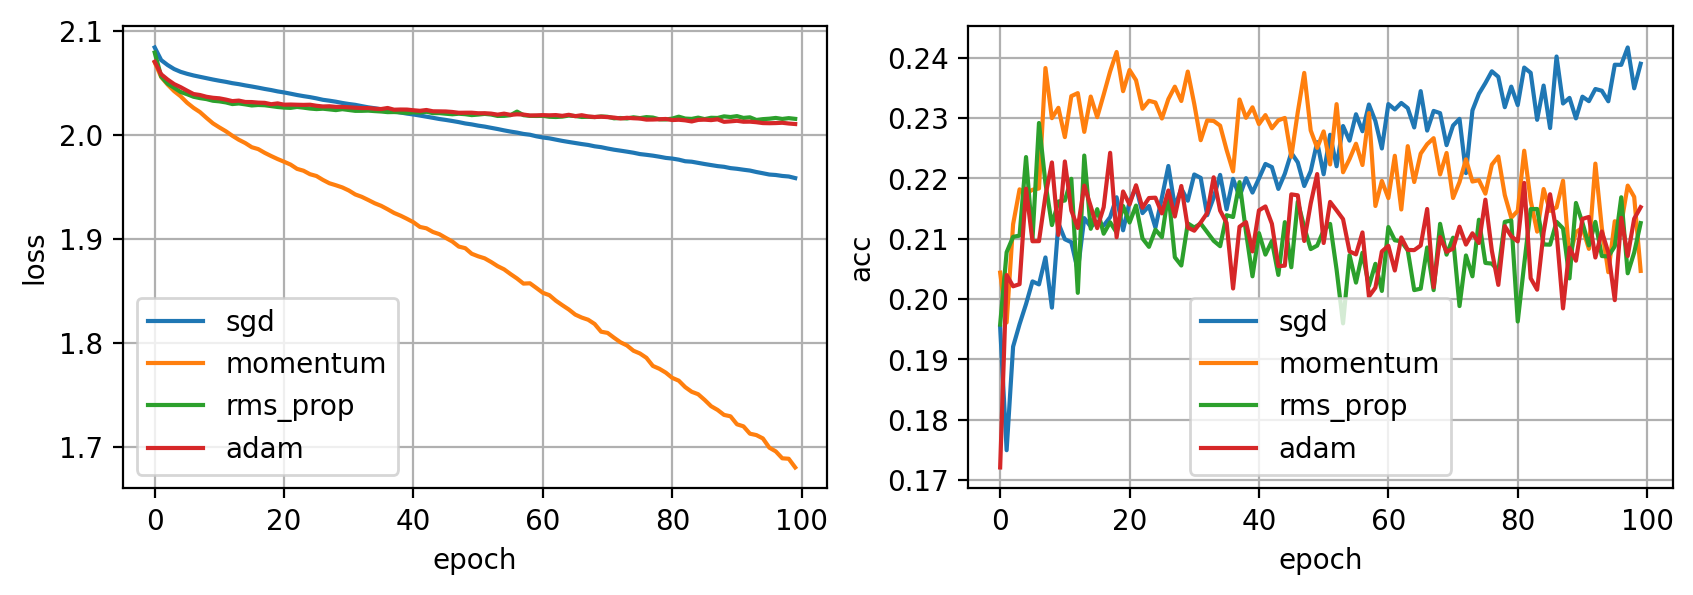

In [15]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

En cuanto a un % de aprendizaje alto el mejor es momentum, pero en la grafica de la derecha podemos que momentum tuvo un overfitting bastante notable, lo que nos deja que sgd fue el mejor metodo de optimizacion, aunque tuvo un gran error fue aprendiendo sin tener overfitting o tenerlo pero con un % muy bajo

# Learning Rate Scheduling
Basado en usar un lr alto para moverse rapido en los valores de perdida y cuanto mas nos acercamos al valle donde esta el minimo se va reduciendo el lr

In [17]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

1. StepLR

Cada 10 epochs, multiplica el lr por 0.1.

In [18]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.20071 en epoch 1
Mejor modelo guardado con acc 0.21340 en epoch 3
Mejor modelo guardado con acc 0.21620 en epoch 6
Mejor modelo guardado con acc 0.21687 en epoch 7
Mejor modelo guardado con acc 0.22270 en epoch 8
Mejor modelo guardado con acc 0.22364 en epoch 10
Epoch 10/30 loss 2.02897 acc 0.22019 val_loss 2.02443 val_acc 0.22364 lr 0.01000
Mejor modelo guardado con acc 0.22783 en epoch 11
Mejor modelo guardado con acc 0.22903 en epoch 13
Mejor modelo guardado con acc 0.23116 en epoch 14
Mejor modelo guardado con acc 0.23131 en epoch 15
Mejor modelo guardado con acc 0.23665 en epoch 16
Mejor modelo guardado con acc 0.23675 en epoch 19
Epoch 20/30 loss 1.98956 acc 0.24091 val_loss 2.00424 val_acc 0.23582 lr 0.00100
Mejor modelo guardado con acc 0.23750 en epoch 23
Mejor modelo guardado con acc 0.23897 en epoch 27
Epoch 30/30 loss 1.98185 acc 0.24316 val_loss 2.00462 val_acc 0.23712 lr 0.00010


2. CyclicLR
Evita quedarse en minimos locales subiendo y bajando el lr, haciendo que explore mas que el anterior ya que hace muchos cambios

In [19]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.20358 en epoch 1
Mejor modelo guardado con acc 0.20932 en epoch 2
Mejor modelo guardado con acc 0.21996 en epoch 3
Mejor modelo guardado con acc 0.22494 en epoch 5
Mejor modelo guardado con acc 0.22999 en epoch 6
Mejor modelo guardado con acc 0.23787 en epoch 9
Epoch 10/30 loss 2.00775 acc 0.23028 val_loss 2.02807 val_acc 0.22214 lr 0.00842
Epoch 20/30 loss 1.96495 acc 0.25015 val_loss 2.00266 val_acc 0.23451 lr 0.00446
Mejor modelo guardado con acc 0.24460 en epoch 23
Epoch 30/30 loss 1.89676 acc 0.28326 val_loss 2.00873 val_acc 0.24176 lr 0.00050


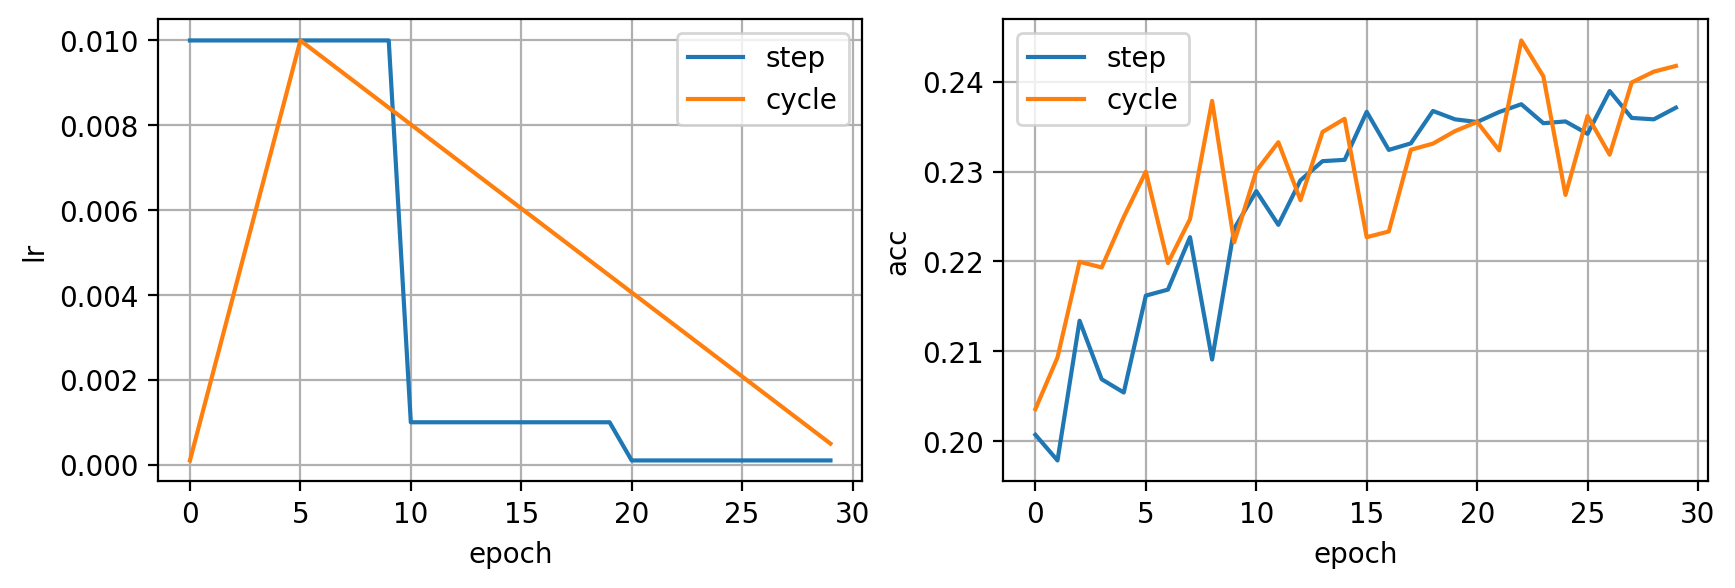

In [20]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Podemos notar que ambas formas de optimizacion son bastante sililares pero cycle se nota que tiene una ligera ventaja por su forma de exploracion extensa lo cual al final har que el resultado final sea un poco mas exacto

# Normalizacion

Calculamos mean y std

In [21]:
mean = (X_train / 255.0).mean()
std  = (X_train / 255.0).std()

Normalizamos los datos

In [22]:
X_train_norm = ((X_train / 255.0) - mean) / std
X_val_norm   = ((X_val / 255.0) - mean) / std

Creamos el dataset y dataloader

In [23]:
dataset_norm = {
    'train': Dataset(X_train_norm, y_train),
    'val': Dataset(X_val_norm, y_val)
}

dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset_norm['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset_norm['val'], batch_size=1000, shuffle=False)
}

Entrenamos el modelo

In [27]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.19624 en epoch 1
Mejor modelo guardado con acc 0.19813 en epoch 2
Epoch 10/100 loss 2.07900 acc 0.18764 val_loss 2.06954 val_acc 0.19624 lr 0.00100
Epoch 20/100 loss 2.07743 acc 0.18773 val_loss 2.06830 val_acc 0.19624 lr 0.00100
Mejor modelo guardado con acc 0.19976 en epoch 25
Mejor modelo guardado con acc 0.20266 en epoch 29
Mejor modelo guardado con acc 0.20608 en epoch 30
Epoch 30/100 loss 2.06255 acc 0.19478 val_loss 2.05184 val_acc 0.20608 lr 0.00100
Mejor modelo guardado con acc 0.20888 en epoch 31
Mejor modelo guardado con acc 0.20949 en epoch 37
Mejor modelo guardado con acc 0.21010 en epoch 40
Epoch 40/100 loss 2.05283 acc 0.19812 val_loss 2.04376 val_acc 0.21010 lr 0.00100
Epoch 50/100 loss 2.05004 acc 0.19949 val_loss 2.04137 val_acc 0.20733 lr 0.00100
Epoch 60/100 loss 2.04858 acc 0.20082 val_loss 2.03943 val_acc 0.20386 lr 0.00100
Epoch 70/100 loss 2.04703 acc 0.20297 val_loss 2.03816 val_acc 0.20613 lr 0.00100
Epoch 80/100 loss 2.04541 ac

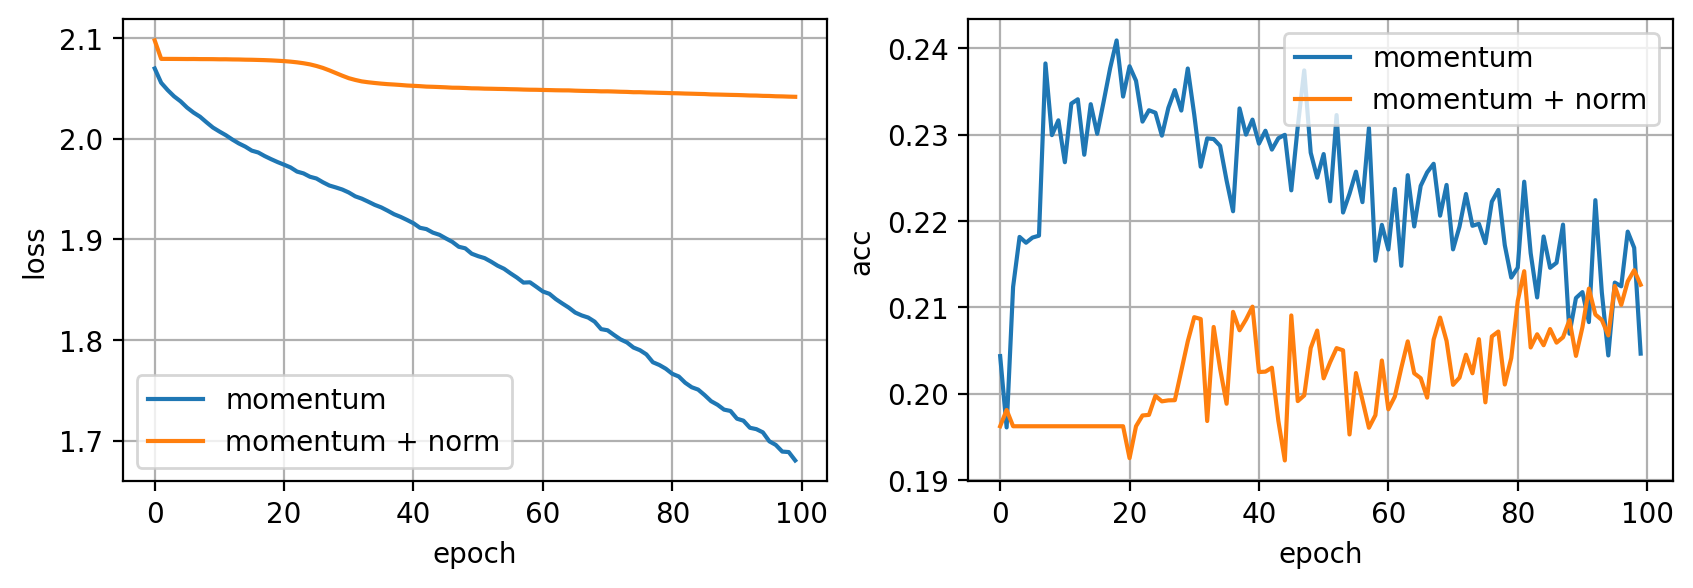

In [39]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

# Batch Normalization

In [41]:
def build_model_n(D_in=64*64, H=100, D_out=9):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [42]:
model = build_model_n()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.22447 en epoch 1
Mejor modelo guardado con acc 0.23177 en epoch 2
Mejor modelo guardado con acc 0.23985 en epoch 3
Mejor modelo guardado con acc 0.24253 en epoch 5
Epoch 10/100 loss 1.89288 acc 0.29175 val_loss 2.03032 val_acc 0.22915 lr 0.00100
Epoch 20/100 loss 1.76285 acc 0.35083 val_loss 2.15691 val_acc 0.21469 lr 0.00100
Epoch 30/100 loss 1.64337 acc 0.40069 val_loss 2.27670 val_acc 0.19908 lr 0.00100
Epoch 40/100 loss 1.53407 acc 0.44653 val_loss 2.49069 val_acc 0.19119 lr 0.00100
Epoch 50/100 loss 1.43746 acc 0.48483 val_loss 2.69990 val_acc 0.19819 lr 0.00100
Epoch 60/100 loss 1.35656 acc 0.51786 val_loss 2.71429 val_acc 0.19056 lr 0.00100
Epoch 70/100 loss 1.28490 acc 0.54164 val_loss 2.80147 val_acc 0.17274 lr 0.00100
Epoch 80/100 loss 1.21672 acc 0.56691 val_loss 3.01952 val_acc 0.15951 lr 0.00100
Epoch 90/100 loss 1.16308 acc 0.58746 val_loss 3.23197 val_acc 0.18469 lr 0.00100
Epoch 100/100 loss 1.11157 acc 0.60680 val_loss 3.19278 val_acc 0.

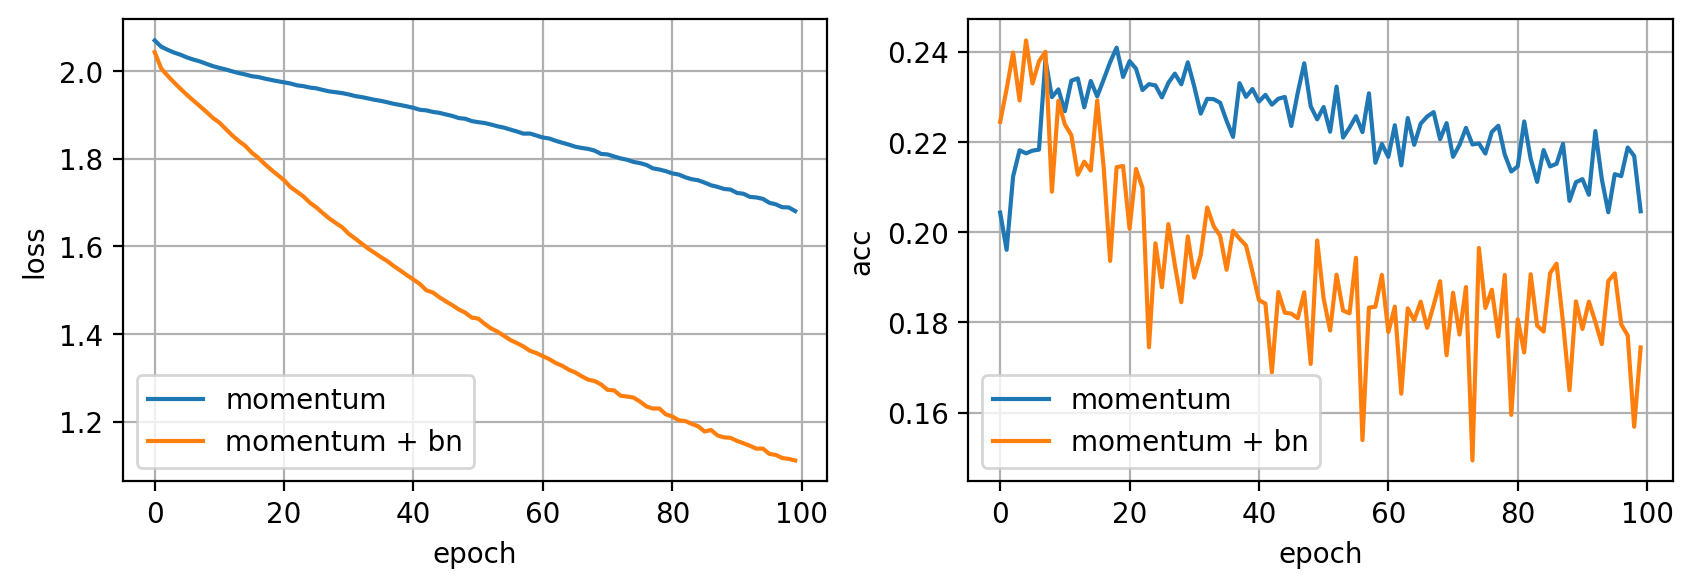

In [43]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

# Regularizacion

En este apartado se eliminara el overfitting de los optimizadores ya usados

Tomamos el codigo anterior para teneer ya en dataset para usarlo

In [44]:
dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}
dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

In [46]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=64*64, H=100, D_out=9):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

def fit(model, dataloader, epochs=200, log_each=10, weight_decay=0):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)
    l, acc = [], []
    val_l, val_acc = [], []
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    return {'epoch': list(range(1, epochs+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [47]:
model = build_model()
hist = fit(model, dataloader)

Epoch 10/200 loss 2.02869 acc 0.21929 val_loss 2.02777 val_acc 0.21486
Epoch 20/200 loss 2.01446 acc 0.22735 val_loss 2.03226 val_acc 0.21762
Epoch 30/200 loss 2.00041 acc 0.23599 val_loss 2.06461 val_acc 0.22301
Epoch 40/200 loss 1.98514 acc 0.23936 val_loss 2.03396 val_acc 0.21795
Epoch 50/200 loss 1.97098 acc 0.24739 val_loss 2.03468 val_acc 0.22990
Epoch 60/200 loss 1.95535 acc 0.25480 val_loss 2.07135 val_acc 0.20979
Epoch 70/200 loss 1.93912 acc 0.26192 val_loss 2.07749 val_acc 0.21412
Epoch 80/200 loss 1.92175 acc 0.26776 val_loss 2.07424 val_acc 0.21058
Epoch 90/200 loss 1.90318 acc 0.27428 val_loss 2.07270 val_acc 0.21370
Epoch 100/200 loss 1.88461 acc 0.28385 val_loss 2.10592 val_acc 0.21674
Epoch 110/200 loss 1.86589 acc 0.29055 val_loss 2.14894 val_acc 0.20066
Epoch 120/200 loss 1.84730 acc 0.29520 val_loss 2.26099 val_acc 0.20216
Epoch 130/200 loss 1.82692 acc 0.30475 val_loss 2.17762 val_acc 0.19772
Epoch 140/200 loss 1.81095 acc 0.31228 val_loss 2.45126 val_acc 0.17823
E

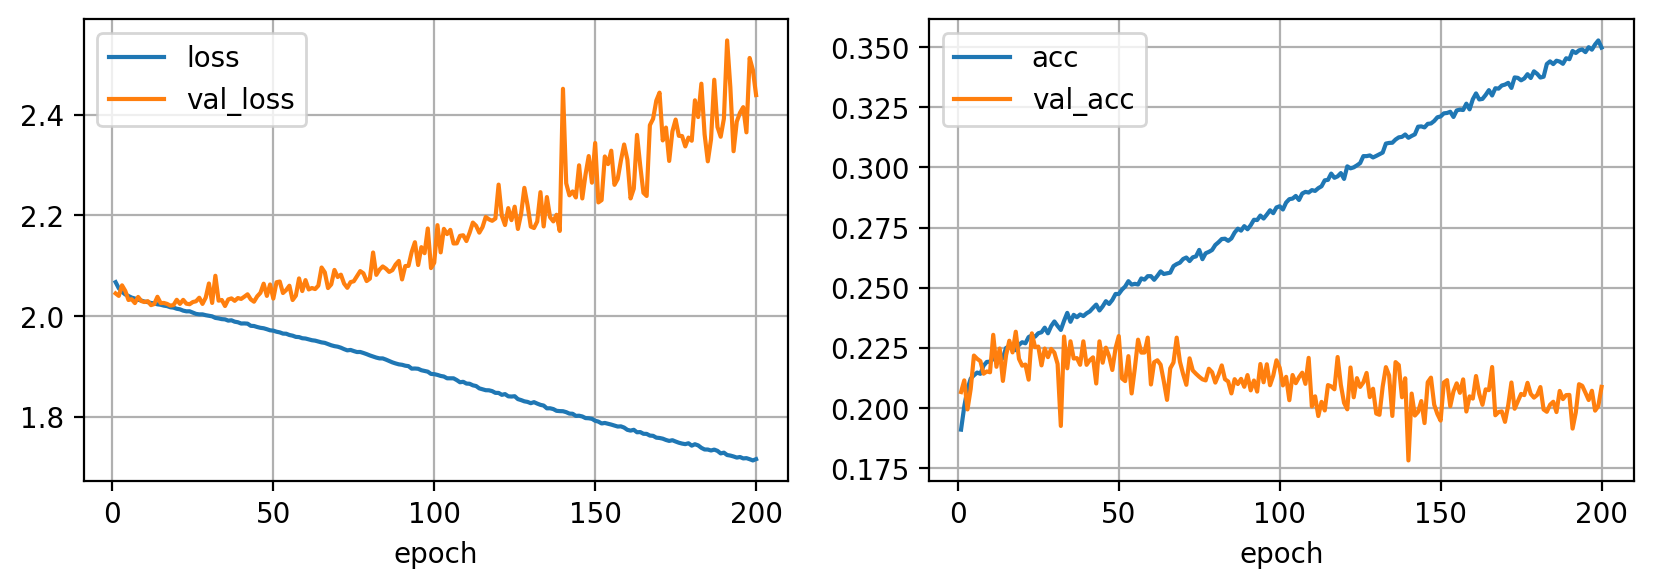

In [48]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# Regularización L2

In [49]:
model = build_model()
hist = fit(model, dataloader, weight_decay=0.01)

Epoch 10/200 loss 2.06604 acc 0.18976 val_loss 2.04981 val_acc 0.18717
Epoch 20/200 loss 2.06627 acc 0.18599 val_loss 2.05073 val_acc 0.20353
Epoch 30/200 loss 2.06653 acc 0.18874 val_loss 2.05451 val_acc 0.19663
Epoch 40/200 loss 2.06653 acc 0.19098 val_loss 2.07638 val_acc 0.18577
Epoch 50/200 loss 2.06630 acc 0.18850 val_loss 2.05743 val_acc 0.19506
Epoch 60/200 loss 2.06589 acc 0.19201 val_loss 2.05367 val_acc 0.19795
Epoch 70/200 loss 2.06624 acc 0.18903 val_loss 2.05722 val_acc 0.20018
Epoch 80/200 loss 2.06579 acc 0.19121 val_loss 2.05806 val_acc 0.18757
Epoch 90/200 loss 2.06603 acc 0.18973 val_loss 2.05297 val_acc 0.20344
Epoch 100/200 loss 2.06612 acc 0.19184 val_loss 2.05926 val_acc 0.18436
Epoch 110/200 loss 2.06645 acc 0.18877 val_loss 2.10065 val_acc 0.17145
Epoch 120/200 loss 2.06601 acc 0.18986 val_loss 2.08374 val_acc 0.17513
Epoch 130/200 loss 2.06635 acc 0.18759 val_loss 2.06312 val_acc 0.19128
Epoch 140/200 loss 2.06574 acc 0.19108 val_loss 2.05126 val_acc 0.20371
E

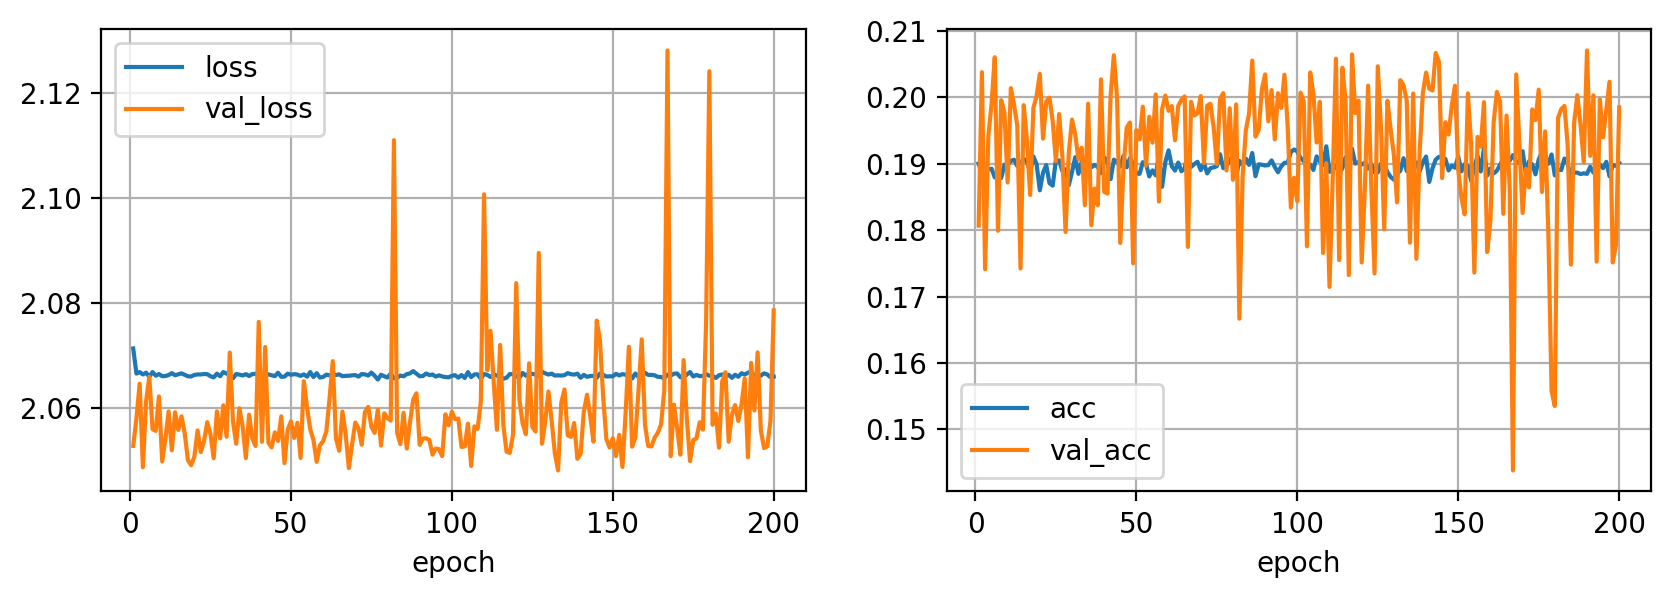

In [50]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# Early Stopping

In [51]:
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=weight_decay)
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

In [52]:
model = build_model()
hist = fit(model, dataloader, early_stopping=20)

Mejor modelo guardado con acc 0.20233 en epoch 1
Mejor modelo guardado con acc 0.20997 en epoch 2
Mejor modelo guardado con acc 0.21385 en epoch 3
Mejor modelo guardado con acc 0.22367 en epoch 4
Epoch 10/200 loss 2.03027 acc 0.21823 val_loss 2.03203 val_acc 0.22188
Mejor modelo guardado con acc 0.22742 en epoch 15
Mejor modelo guardado con acc 0.22826 en epoch 19
Epoch 20/200 loss 2.01682 acc 0.22480 val_loss 2.05072 val_acc 0.20621
Mejor modelo guardado con acc 0.22995 en epoch 23
Mejor modelo guardado con acc 0.23363 en epoch 29
Epoch 30/200 loss 2.00583 acc 0.22911 val_loss 2.02575 val_acc 0.21820
Mejor modelo guardado con acc 0.23559 en epoch 38
Epoch 40/200 loss 1.99416 acc 0.23590 val_loss 2.04051 val_acc 0.22673
Epoch 50/200 loss 1.98291 acc 0.23952 val_loss 2.02876 val_acc 0.22098
Entrenamiento detenido en epoch 58 por no mejorar en 20 epochs seguidas


C:\Users\KUR0\AppData\Local\Temp\ipykernel_17556\3929446251.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


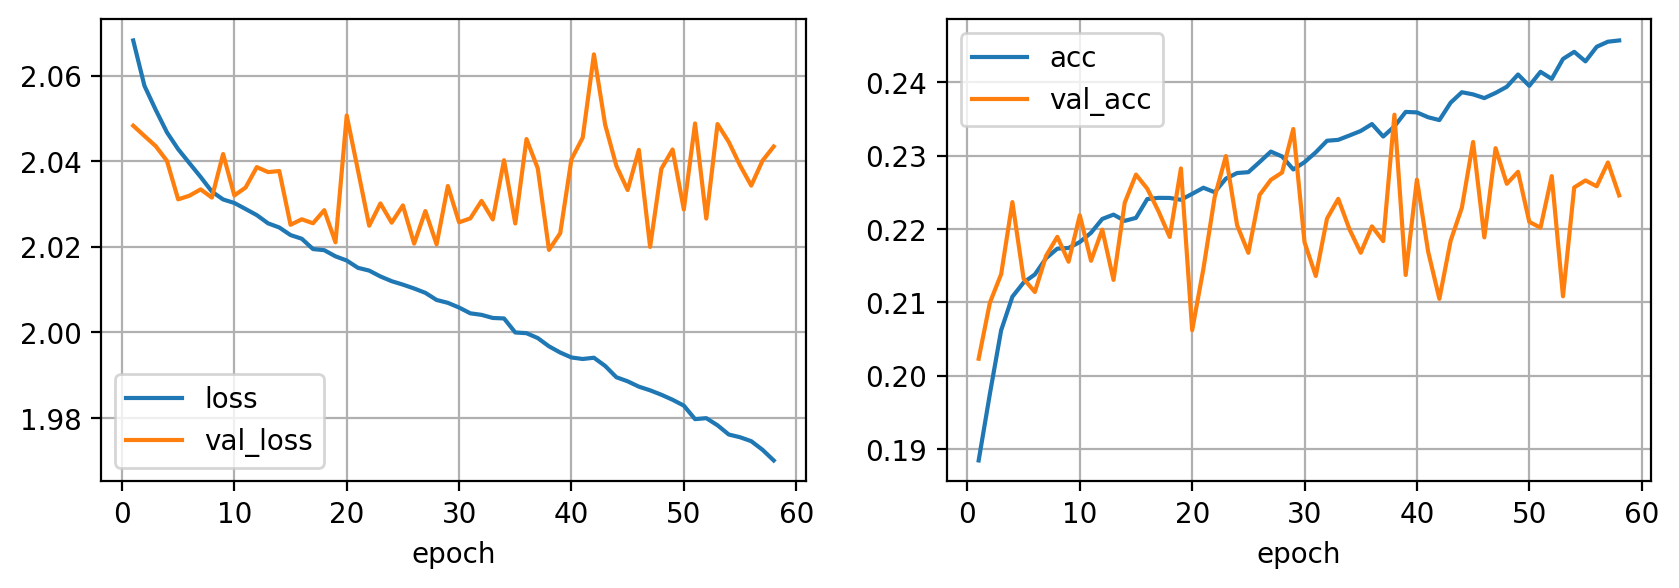

In [53]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

# Dropout

In [54]:
def build_model(D_in=64*64, H=100, D_out=9, p=0):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [55]:
model = build_model(p=0.5)
hist = fit(model, dataloader)

Mejor modelo guardado con acc 0.20144 en epoch 1
Epoch 10/200 loss 2.07423 acc 0.18592 val_loss 2.06049 val_acc 0.17397
Epoch 20/200 loss 2.07282 acc 0.18643 val_loss 2.06239 val_acc 0.19596
Epoch 30/200 loss 2.07362 acc 0.18379 val_loss 2.05853 val_acc 0.19624
Epoch 40/200 loss 2.07254 acc 0.18562 val_loss 2.05998 val_acc 0.18835
Mejor modelo guardado con acc 0.20208 en epoch 46
Epoch 50/200 loss 2.07110 acc 0.18732 val_loss 2.05695 val_acc 0.18857
Epoch 60/200 loss 2.07124 acc 0.18603 val_loss 2.06093 val_acc 0.19789
Epoch 70/200 loss 2.07048 acc 0.18642 val_loss 2.05897 val_acc 0.19713
Epoch 80/200 loss 2.06962 acc 0.18696 val_loss 2.05670 val_acc 0.19618
Epoch 90/200 loss 2.06953 acc 0.18780 val_loss 2.05824 val_acc 0.18437
Epoch 100/200 loss 2.06980 acc 0.18593 val_loss 2.05863 val_acc 0.19822
Epoch 110/200 loss 2.06867 acc 0.18844 val_loss 2.05491 val_acc 0.19045
Epoch 120/200 loss 2.06822 acc 0.18844 val_loss 2.05466 val_acc 0.19655
Mejor modelo guardado con acc 0.20259 en epoch

C:\Users\KUR0\AppData\Local\Temp\ipykernel_17556\3929446251.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


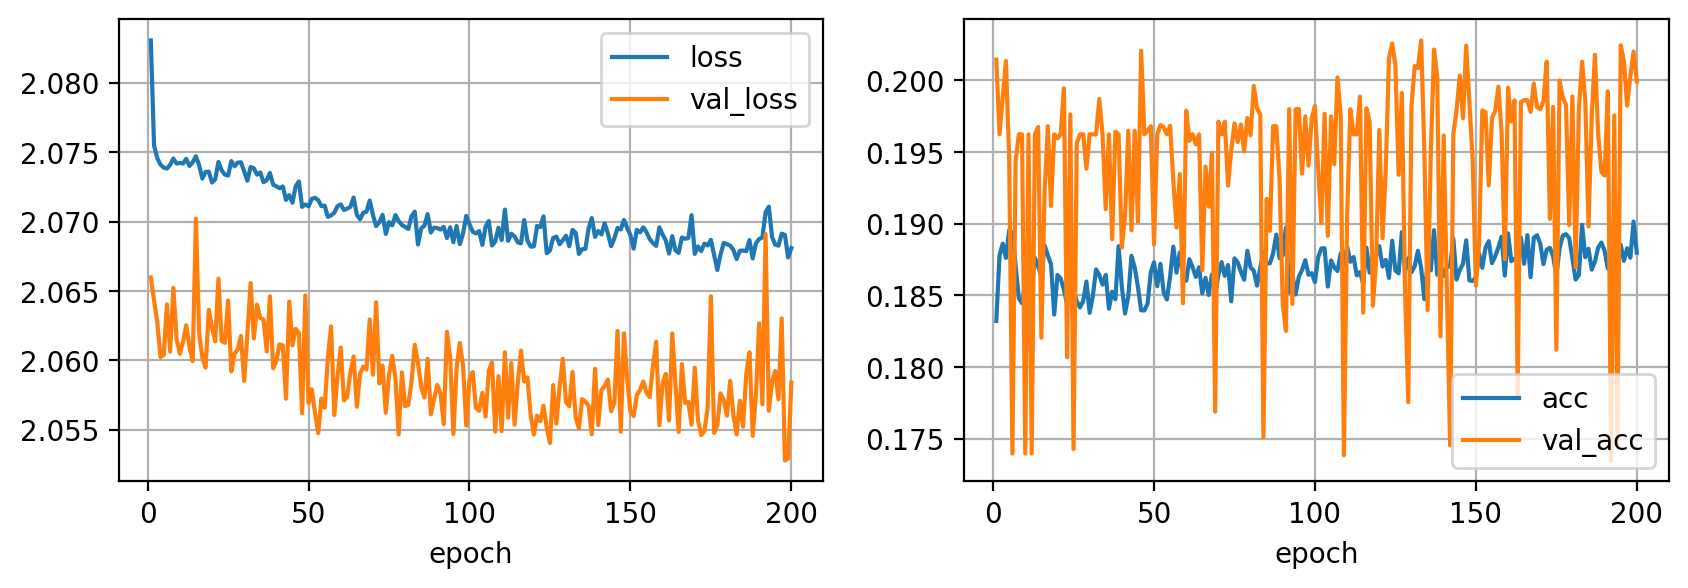

In [56]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()